In [1]:
from eventQuery import EventQueryAPI

eq_api = EventQueryAPI(
    chunk_dir="./chunks4spark",
    event2pixels_dir="./event_to_pixels_out"
)


[INFO] Building chunk index map ...
[INFO] Loading event->pixels inverted index ...
[INFO] Initialization complete.


In [2]:
df_2d = eq_api.query(event_id=92, modes=["2d"])
df_2d

,event_id,chunk_file,t_val,lat_r,lon_r,Latitude,Longitude,TAI_start,Profile_time,DEM_elevation,Surface_wind,Sigma_Zero,Near_surface_reflectivity,Surface_type,SurfaceHeightBin,Lowest_sig_layer_top,MODIS_scene_char
0,92,chunk_3050000_3100000,766556992.0,14732,49077,39.775902,132.506882,766553344.0,3630.879883,-9999.0,10.815128,52.0,-0.21,0.0,105.0,10.682000,9.0
1,92,chunk_3050000_3100000,766556992.0,14700,49087,39.689816,132.533890,766553344.0,3629.439941,-9999.0,10.737046,330.0,1.42,0.0,105.0,10.425000,9.0
2,92,chunk_3050000_3100000,766556992.0,14707,49084,39.708946,132.527893,766553344.0,3629.760010,-9999.0,10.753834,272.0,-3.45,0.0,105.0,10.428000,9.0
3,92,chunk_3050000_3100000,766556992.0,14711,49083,39.718513,132.524902,766553344.0,3629.919922,-9999.0,10.762353,291.0,-7.59,0.0,105.0,10.430000,9.0
4,92,chunk_3050000_3100000,766556992.0,14721,49080,39.747208,132.515884,766553344.0,3630.399902,-9999.0,10.788380,120.0,0.90,0.0,105.0,10.676001,9.0
5,92,chunk_3050000_3100000,766556992.0,14735,49076,39.785469,132.503876,766553344.0,3631.040039,-9999.0,10.824205,205.0,0.07,0.0,105.0,10.684001,9.0
6,92,chunk_3050000_3100000,766556992.0,14693,49089,39.670685,132.539886,766553344.0,3629.120117,-9999.0,10.720584,270.0,1.68,0.0,105.0,10.181001,9.0
7,92,chunk_3050000_3100000,766556992.0,14725,49079,39.756771,132.512894,766553344.0,3630.560059,-9999.0,10.797216,9.0,2.12,0.0,105.0,10.678000,9.0
8,92,chunk_3050000_3100000,766556992.0,14682,49092,39.641987,132.548874,766553344.0,3628.639893,-9999.0,10.696509,-282.0,7.39,0.0,105.0,10.175000,9.0
9,92,chunk_3050000_3100000,766556992.0,14714,49082,39.728077,132.521896,766553344.0,3630.080078,-9999.0,10.770947,231.0,-9.42,0.0,105.0,10.432000,9.0


[INFO] Building chunk index map ...


ERROR 1: PROJ: proj_create_from_database: Open of /home/d376li/anaconda3/envs/cis/share/proj failed


[INFO] Loading event->pixels inverted index ...
[INFO] Initialization complete.


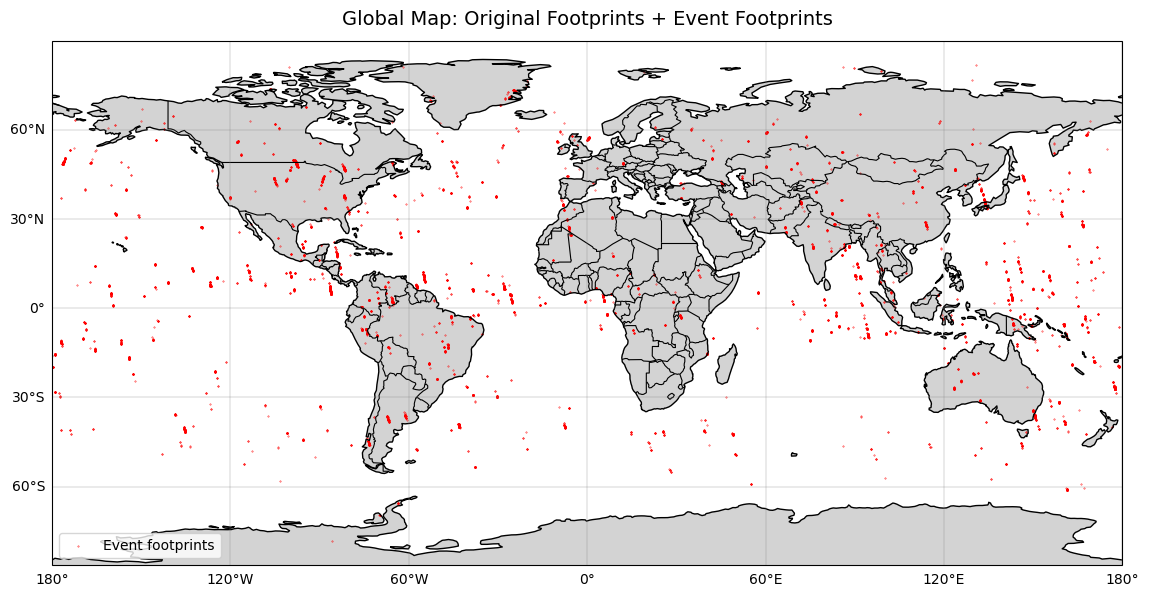

In [3]:
import h5py
import numpy as np
import datetime
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import h5py
import numpy as np
import datetime
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_original_with_event_overlays(eq_api, original_h5_path):
    """
    1) Load original footprints from `original_h5_path` into lat, lon, time.
    2) Plot them on a Cartopy map (colored by days from earliest).
    3) Overlay all event footprints from eq_api in red dots (size=0.1).
    4) Colorbar shows only two tick labels (earliest date, latest date).
    """

    # --------------------------------------------------
    # Load the original dataset
    # --------------------------------------------------
    with h5py.File(original_h5_path, "r") as hf:
        attrs = hf["footprint_attributes"]
        lat_all = attrs[:, 0]
        lon_all = attrs[:, 1]
        tai_start = attrs[:, 2]
        profile_time = attrs[:, 3]

    # TAI seconds since 1993-01-01
    tai_seconds = tai_start + profile_time
    epoch_1993 = datetime.datetime(1993,1,1,0,0,0, tzinfo=datetime.timezone.utc)
    times_dt = [epoch_1993 + datetime.timedelta(seconds=float(t)) for t in tai_seconds]

    # Earliest and latest datetimes
    min_dt = min(times_dt)
    max_dt = max(times_dt)

    # Convert times to "days from earliest"
    days_from_earliest = np.array([(td - min_dt).total_seconds() / 86400.0 for td in times_dt])
    min_val = 0.0  # earliest
    max_val = days_from_earliest.max()

    # --------------------------------------------------
    # Combine all event footprints for the overlay
    # --------------------------------------------------
    event_ids = eq_api.list_events()
    lat_events = []
    lon_events = []

    for e in event_ids:
        df = eq_api.query(e, modes=("2d",))  # "Latitude", "Longitude", ...
        if not df.empty:
            lat_events.extend(df["Latitude"].tolist())
            lon_events.extend(df["Longitude"].tolist())

    # --------------------------------------------------
    # Make the Cartopy map
    # --------------------------------------------------
    fig = plt.figure(figsize=(12,6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_title("Global Map: Original Footprints + Event Footprints", fontsize=14, pad=12)

    # Basic features: coastlines, borders, etc.
    ax.coastlines(resolution='110m', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='black')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='white')

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.8)
    gl.top_labels = False
    gl.right_labels = False

    '''
    # --------------------------------------------------
    # 1) Plot original footprints (colored by "days from earliest")
    # --------------------------------------------------
    sc1 = ax.scatter(
        lon_all, lat_all,
        c=days_from_earliest, s=1, cmap='viridis',
        alpha=0.7, transform=ccrs.PlateCarree()
    )

    # Create a colorbar
    cbar = plt.colorbar(sc1, ax=ax, orientation='horizontal', pad=0.05, fraction=0.045)

    # Remove intermediate ticks; show only earliest & latest dates
    cbar.set_ticks([min_val, max_val])
    date_format = "%Y-%m-%d"  # year-month-day
    start_label = min_dt.strftime(date_format)
    end_label   = max_dt.strftime(date_format)
    cbar.set_ticklabels([start_label, end_label])
    '''

    # --------------------------------------------------
    # 2) Overlay event footprints in red
    # --------------------------------------------------
    sc2 = ax.scatter(
        lon_events, lat_events,
        color='red', s=0.1, alpha=1.0,
        transform=ccrs.PlateCarree(),
        label="Event footprints"
    )

    # Add a legend entry for red dots
    ax.legend(loc="lower left", scatterpoints=1)

    plt.tight_layout()
    plt.show()



# Example usage:
# from eventQuery import EventQueryAPI
eq_api = EventQueryAPI(chunk_dir="./chunks4spark", event2pixels_dir="./event_to_pixels_out")
plot_original_with_event_overlays(eq_api, "preprocessed_data/train_data_transfer_fbz_1_thickness_18_bn_20000_gr_800_unshuffled_update.h5")


In [4]:
eventList = eq_api.list_events()
event2size = dict(list(map(lambda event_no: (event_no, len(eq_api.query(event_no, modes=("2d",)))), eventList)))

In [5]:
event2size

{0: 1,
 1: 2,
 2: 2,
 3: 1,
 4: 3,
 5: 1,
 6: 14,
 7: 3,
 8: 3,
 9: 88,
 10: 1,
 11: 2,
 12: 1,
 13: 3,
 14: 1,
 15: 1,
 16: 1,
 17: 6,
 18: 2,
 19: 2,
 20: 3,
 21: 3,
 22: 1,
 23: 3,
 24: 10,
 25: 1,
 26: 1,
 27: 1,
 28: 1,
 29: 2,
 30: 3,
 31: 1,
 32: 1,
 33: 1,
 34: 3,
 35: 2,
 36: 7,
 37: 1,
 38: 1,
 39: 3,
 40: 1,
 41: 2,
 42: 1,
 43: 1,
 44: 3,
 45: 2,
 46: 14,
 47: 1,
 48: 1,
 49: 1,
 50: 6,
 51: 1,
 52: 1,
 53: 4,
 54: 1,
 55: 1,
 56: 30,
 57: 3,
 58: 1,
 59: 2,
 60: 2,
 61: 1,
 62: 3,
 63: 5,
 64: 2,
 65: 1,
 66: 1,
 67: 8,
 68: 1,
 69: 1,
 70: 3,
 71: 2,
 72: 3,
 73: 1,
 74: 3,
 75: 2,
 76: 1,
 77: 1,
 78: 2,
 79: 1,
 80: 42,
 81: 1,
 82: 1,
 83: 1,
 84: 1,
 85: 1,
 86: 1,
 87: 1,
 88: 13,
 89: 6,
 90: 2,
 91: 9,
 92: 16,
 93: 1,
 94: 2,
 95: 9,
 96: 1,
 97: 3,
 98: 5,
 99: 5,
 100: 1,
 101: 2,
 102: 5,
 103: 1,
 104: 1,
 105: 1,
 106: 1,
 107: 2,
 108: 14,
 109: 2,
 110: 2,
 111: 4,
 112: 1,
 113: 1,
 114: 2,
 115: 15,
 116: 1,
 117: 4,
 118: 3,
 119: 2,
 120: 7,
 121: 1,
 1

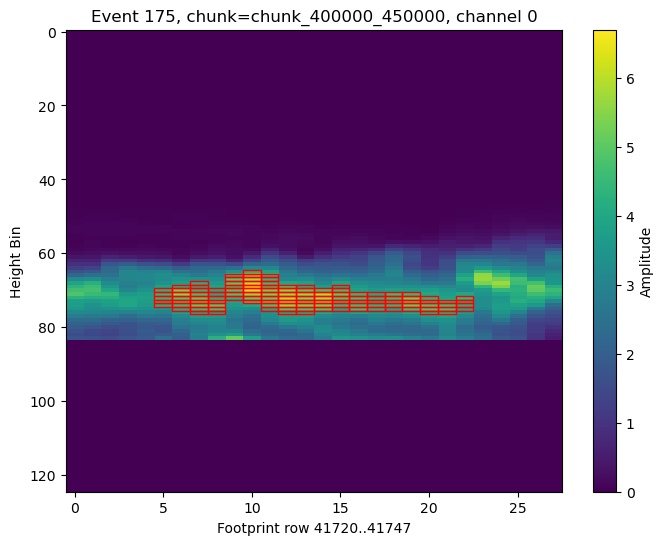

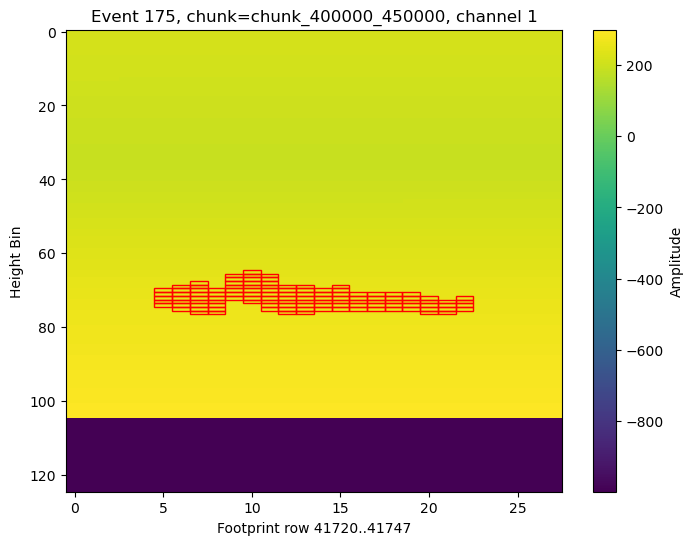

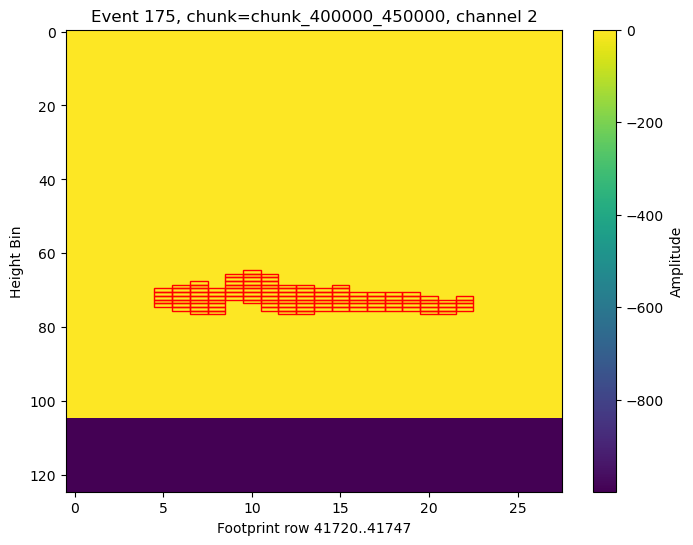

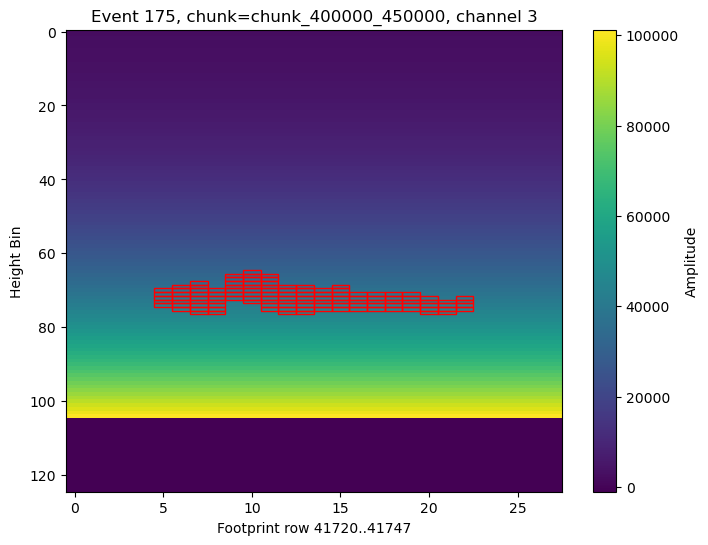

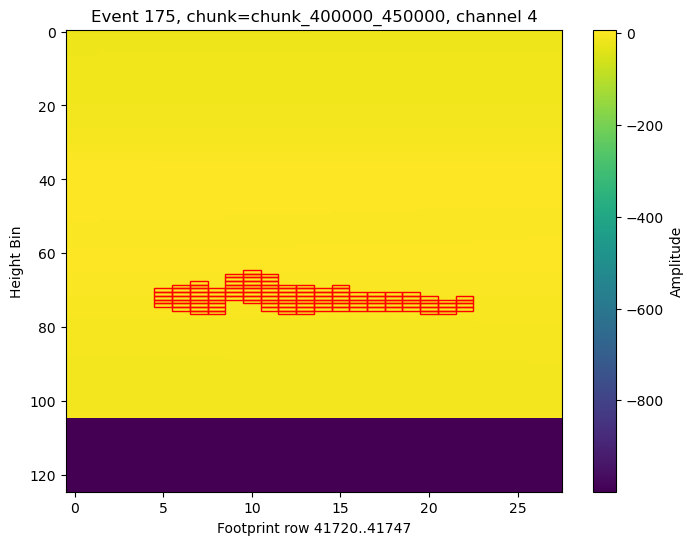

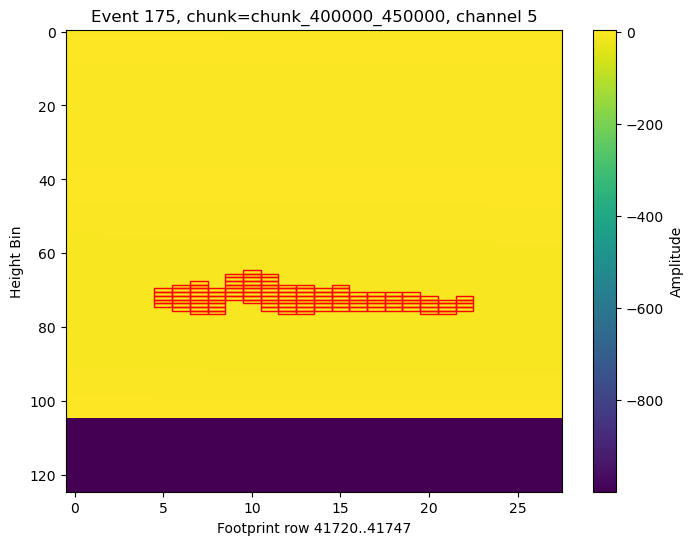

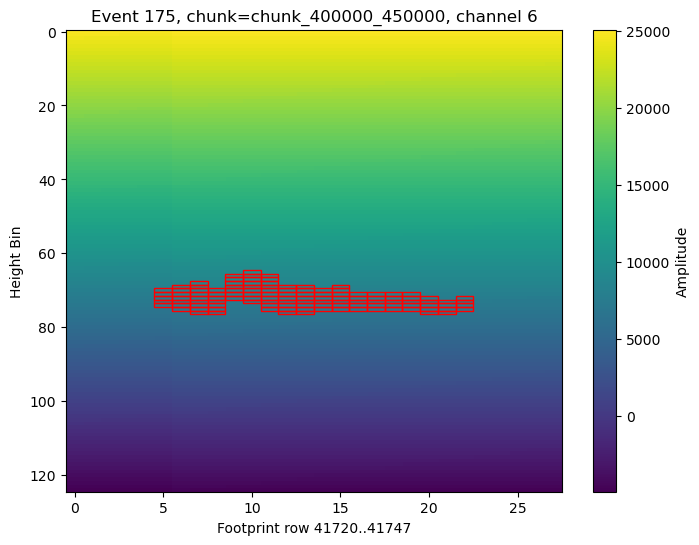

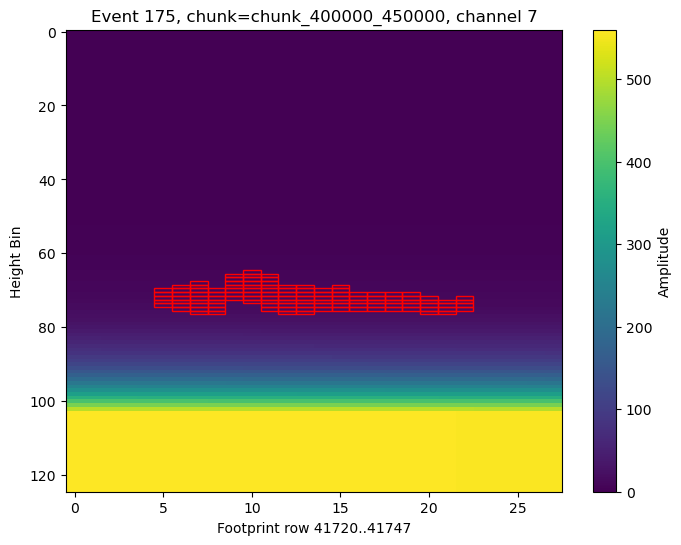

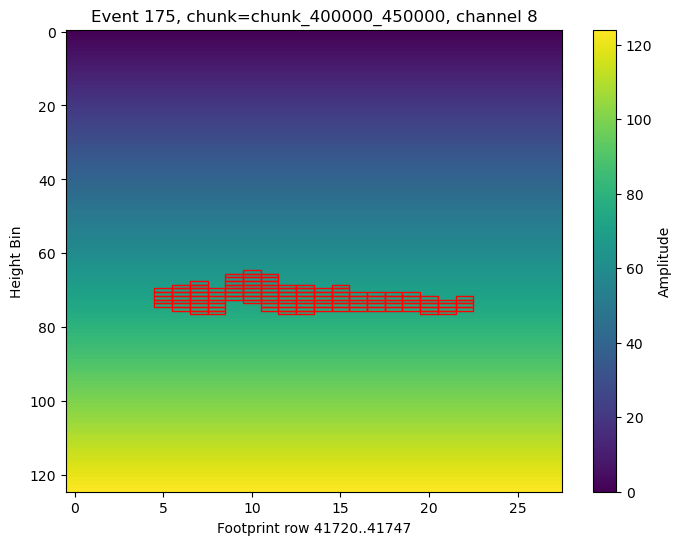

(    event_id           chunk_file        t_val  lat_r  lon_r   Latitude  \
 0        175  chunk_400000_450000  762402880.0  -6627  63194 -17.892727   
 1        175  chunk_400000_450000  762402880.0  -6591  63186 -17.796307   
 2        175  chunk_400000_450000  762402880.0  -6648  63199 -17.950579   
 3        175  chunk_400000_450000  762402880.0  -6613  63191 -17.854158   
 4        175  chunk_400000_450000  762402880.0  -6620  63193 -17.873444   
 5        175  chunk_400000_450000  762402880.0  -6609  63190 -17.844517   
 6        175  chunk_400000_450000  762402880.0  -6641  63198 -17.931295   
 7        175  chunk_400000_450000  762402880.0  -6634  63196 -17.912010   
 8        175  chunk_400000_450000  762402880.0  -6638  63197 -17.921654   
 9        175  chunk_400000_450000  762402880.0  -6616  63192 -17.863802   
 10       175  chunk_400000_450000  762402880.0  -6623  63193 -17.883085   
 11       175  chunk_400000_450000  762402880.0  -6602  63189 -17.825233   
 12       17

In [6]:
eq_api.query(175, modes=("2d", "3d"))

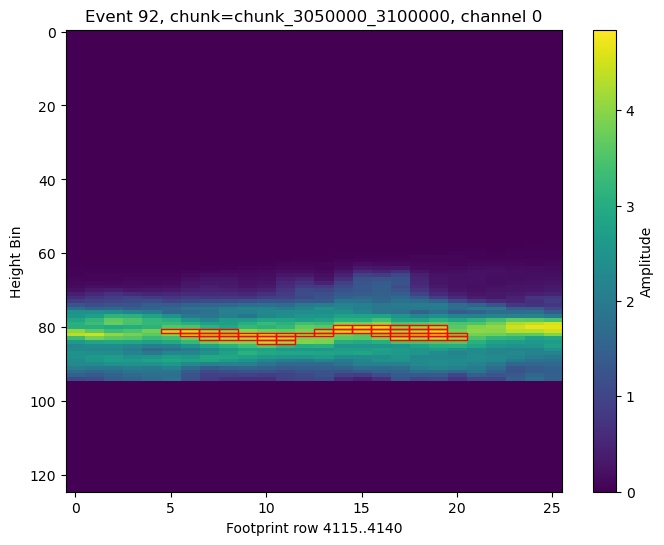

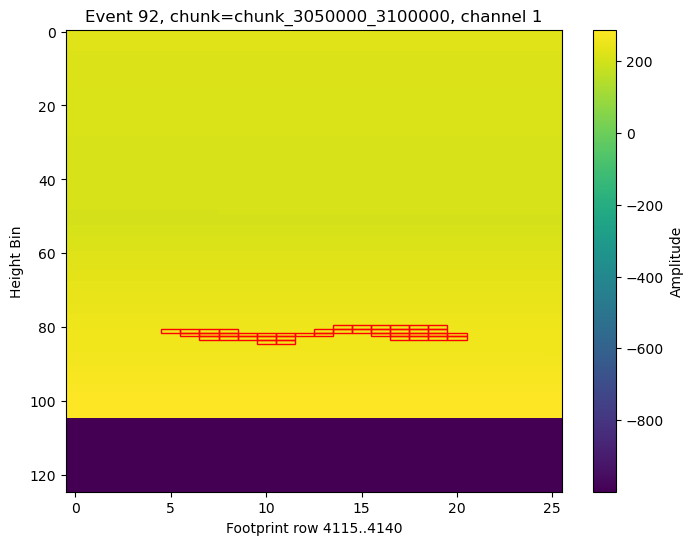

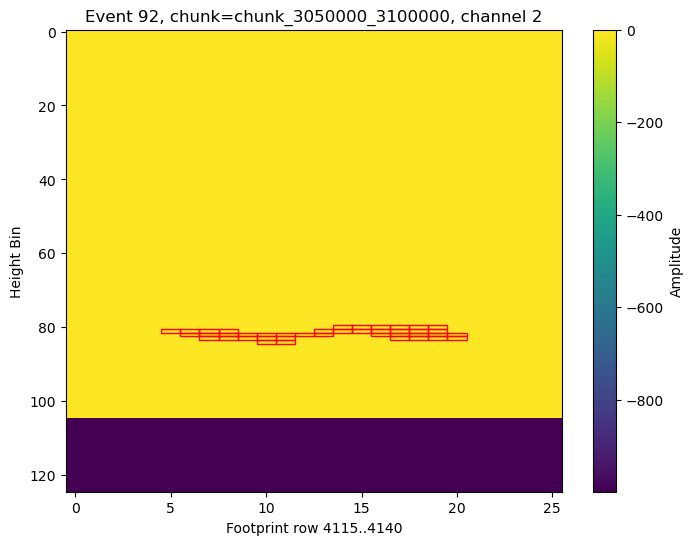

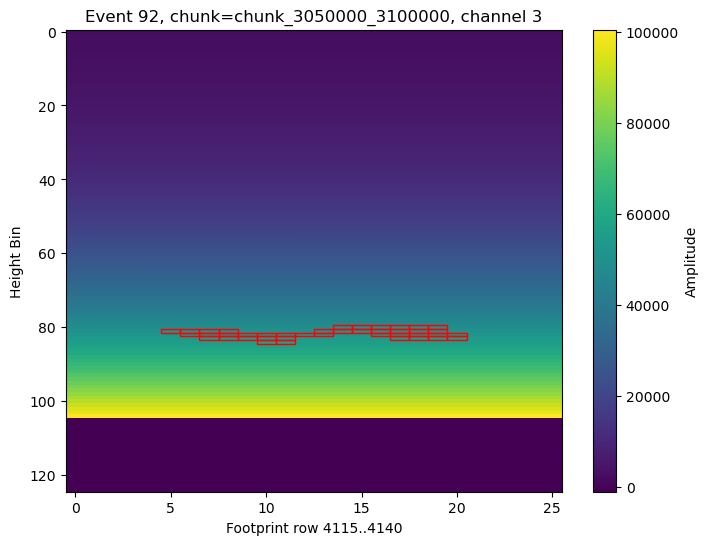

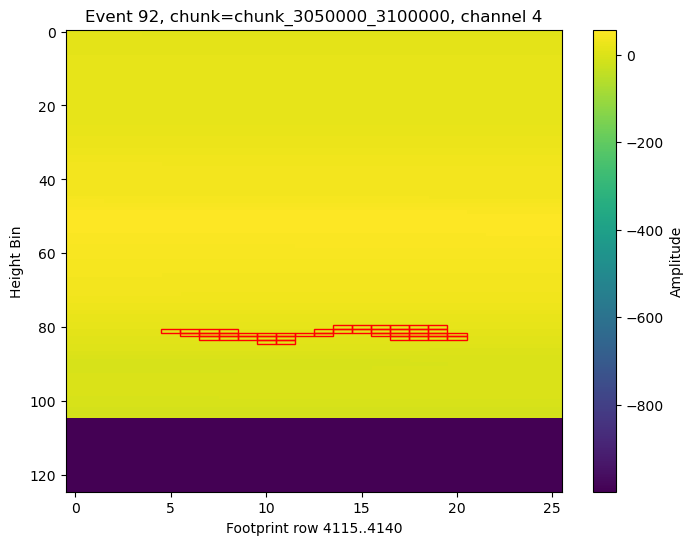

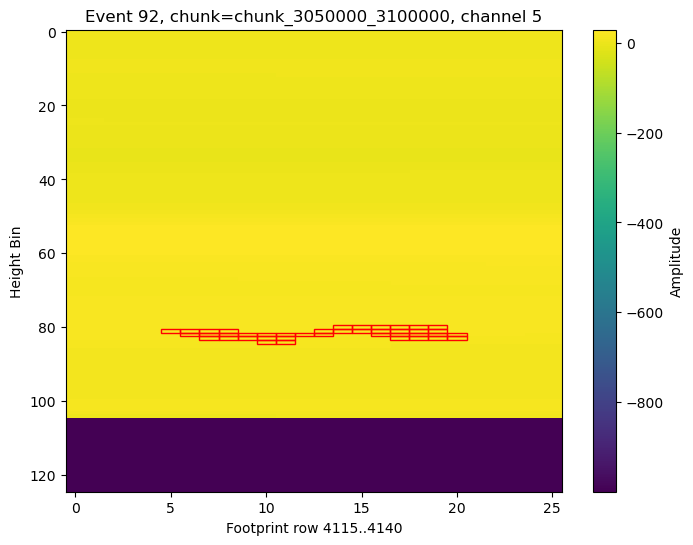

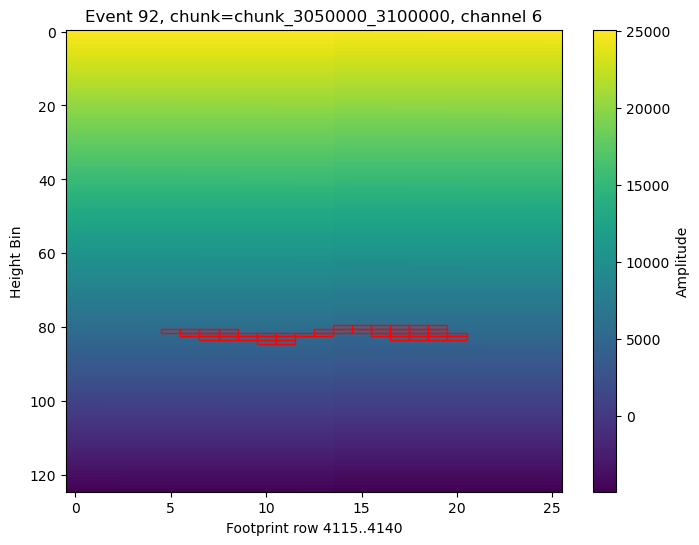

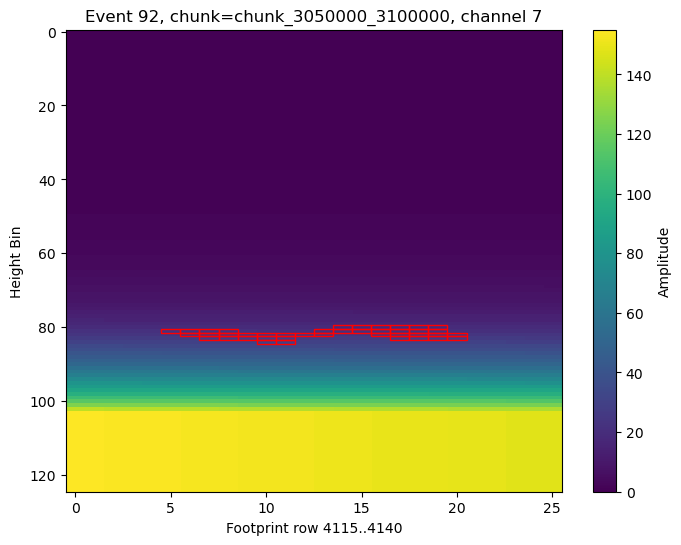

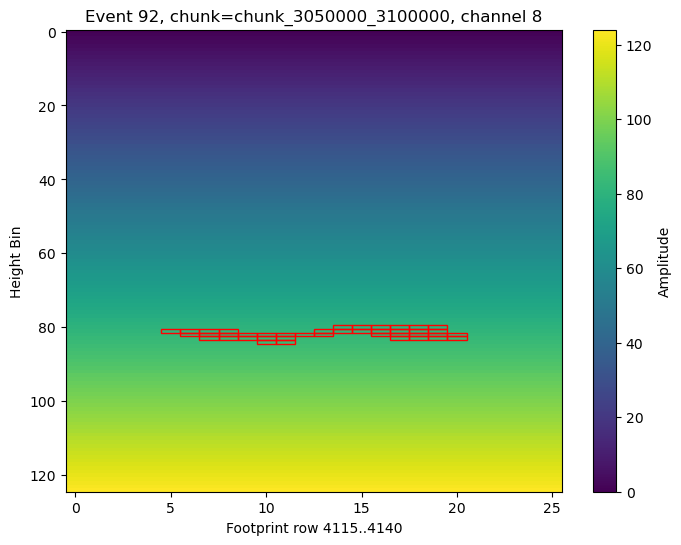

In [7]:
df9, profiles9 = eq_api.query(92, modes=("2d", "3d"))

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import math

def plot_event_size_histograms(
    eq_api,
    xbins_tuple=(50, 50, 50),
    xtick_steps=(1.0, 5.0, 50.0)
):
    """
    Plot 3 histograms (Height, Width, Area) side-by-side for all events in eq_api,
    each with an empirical PDF overlay, using frequency (count) on the y-axis.

    Parameters
    ----------
    eq_api : EventQueryAPI
        eq_api.event_to_pixels => dict of event_id -> list of BFS-labeled pixels
        (chunk_file, t, lat_r, lon_r, h_val).

    xbins_tuple : (height_bins, width_bins, area_bins)
        Each can be an integer (meaning "use that many bins"), or an array of bin edges.
        Defaults to (50, 50, 50).

    xtick_steps : (height_step, width_step, area_step)
        The spacing between labeled ticks on the x-axis for each subplot,
        e.g. (1.0, 5.0, 50.0).

    For each event:
      * height (km) = (#vertical_bins) * 0.24 km
      * width  (km) = (#unique_footprints) * 1.5 km
      * area  (km^2) = height_km * width_km

    The histograms use raw counts on the y-axis. The empirical PDF is rescaled
    to match that same vertical scale, so you see both on the same axis.

    Example usage:
      plot_event_size_histograms(eq_api, xbins_tuple=(40,30,30), xtick_steps=(0.5,2.5,25))
    """

    PIXEL_HEIGHT_KM = 0.24  # 240 m
    PIXEL_WIDTH_KM  = 1.5

    # Gather arrays of heights, widths, areas
    all_heights = []
    all_widths  = []
    all_areas   = []

    # eq_api.event_to_pixels => {event_id: [(chunk_file, t, lat_r, lon_r, h_val), ...]}
    for event_id, pixels in eq_api.event_to_pixels.items():
        if not pixels:
            continue

        # vertical dimension
        h_vals = [p[4] for p in pixels]  # p[4] is the vertical bin index
        min_h = min(h_vals)
        max_h = max(h_vals)
        height_in_pixels = (max_h - min_h + 1)
        height_km = height_in_pixels * PIXEL_HEIGHT_KM

        # horizontal dimension
        # each footprint => (chunk_file, t, lat_r, lon_r)
        footprints = set((p[0], p[1], p[2], p[3]) for p in pixels)
        width_in_pixels = len(footprints)
        width_km = width_in_pixels * PIXEL_WIDTH_KM

        # area
        area_km2 = height_km * width_km

        all_heights.append(height_km)
        all_widths.append(width_km)
        all_areas.append(area_km2)

    # Convert to numpy arrays
    all_heights = np.array(all_heights)
    all_widths  = np.array(all_widths)
    all_areas   = np.array(all_areas)

    # Parse bin specs
    height_bins, width_bins, area_bins = xbins_tuple

    def make_bins(data, bins):
        """
        If bins is int => produce that many bins from data.min()..data.max().
        Otherwise, assume bins is an array of edges.
        """
        if isinstance(bins, int):
            dmin, dmax = data.min(), data.max()
            if dmin == dmax:
                # edge case if all data is identical
                dmax = dmin + 1e-9
            return np.linspace(dmin, dmax, bins+1)
        else:
            return np.asarray(bins)

    height_xbins = make_bins(all_heights, height_bins)
    width_xbins  = make_bins(all_widths,  width_bins)
    area_xbins   = make_bins(all_areas,   area_bins)

    # Set up subplots: 3 side-by-side
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    def plot_hist_and_pdf(ax, data, xbins, xstep, xlabel, title):
        """
        Plot a frequency histogram + a scaled PDF overlay on axis ax.
        data: 1D array
        xbins: array of bin edges
        xstep: spacing for x-axis labeled ticks
        """
        # 1) Make the histogram in terms of raw counts
        counts, edges, patches = ax.hist(data, bins=xbins, alpha=0.4, edgecolor='black')
        ax.set_ylabel("Frequency", fontsize=12)

        # 2) Overlap an empirical PDF.
        #    We'll scale pdf so that area under pdf ~ total number of data points
        #    The integral of the PDF from min..max => 1, so we multiply by N * avg_bin_size
        N = len(data)
        dmin, dmax = data.min(), data.max()
        bin_count = len(xbins) - 1  # number of bins
        if bin_count < 1:
            return  # no bins => skip
        avg_bin_size = (dmax - dmin) / bin_count

        # build x-values for the pdf
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(data)
        xvals = np.linspace(dmin, dmax, 300)
        pdf_raw = kde(xvals)            # integral=1
        pdf_scaled = pdf_raw * N * avg_bin_size

        ax.plot(xvals, pdf_scaled, 'r-', linewidth=2, alpha=0.8)  # no label => no legend

        # 3) x-axis labeling
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_title(title, fontsize=14)

        # define ticks at intervals of xstep
        import math
        start_tick = xstep * math.floor(dmin/xstep)
        end_tick   = xstep * math.ceil(dmax/xstep)
        if start_tick == end_tick:
            end_tick = start_tick + xstep
        tick_positions = np.arange(start_tick, end_tick + 0.001, xstep)
        ax.set_xticks(tick_positions)

    # 1) Height
    plot_hist_and_pdf(
        axs[0],
        all_heights, height_xbins, xtick_steps[0],
        xlabel="Event Height (km)",
        title="Event Height Distribution"
    )

    # 2) Width
    plot_hist_and_pdf(
        axs[1],
        all_widths, width_xbins, xtick_steps[1],
        xlabel="Event Width (km)",
        title="Event Width Distribution"
    )

    # 3) Area
    plot_hist_and_pdf(
        axs[2],
        all_areas, area_xbins, xtick_steps[2],
        xlabel="Event Area (km$^2$)",
        title="Event Area Distribution"
    )

    plt.tight_layout()
    plt.show()


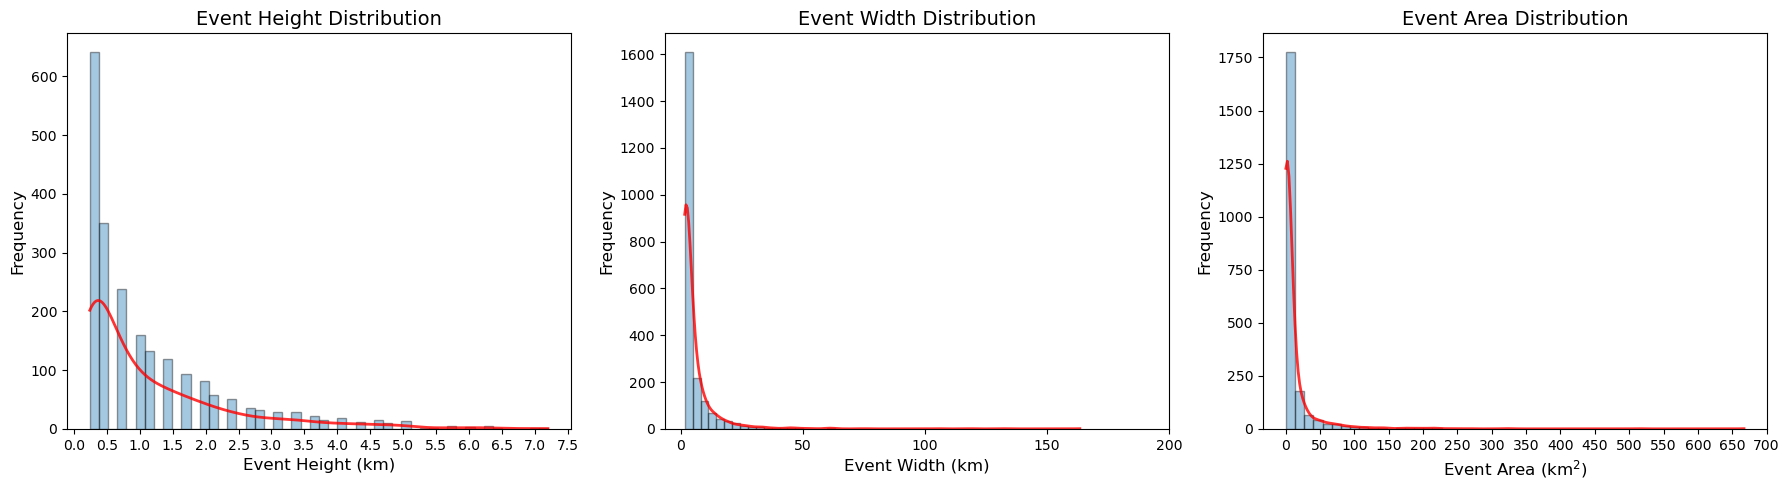

In [9]:
plot_event_size_histograms(eq_api, xbins_tuple=(50, 50, 50), xtick_steps=(0.5, 50.0, 50.0))

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def plot_top9_events_channel0(eq_api):
    """
    Plots the first channel (channel 0) for 9 events, but with a twist:
      - We skip the 9th-largest event and use the 10th-largest event instead.
      - The 9 subplots are arranged in a 3x3 grid.
      - Each subplot shows an amplitude matrix (height × footprints),
        with BFS-labeled pixels indicated by red squares.

    Parameters
    ----------
    eq_api : EventQueryAPI
        Must have eq_api.event_to_pixels => BFS-labeled pixel info,
        and .query(...) to retrieve feats_dict for 3D data (with show_3d_plots=False).
    """

    # 1) Identify top 10 events by BFS-labeled pixel count
    event_counts = [(eid, len(pixels)) for eid, pixels in eq_api.event_to_pixels.items()]
    if not event_counts:
        print("No events found in eq_api.event_to_pixels.")
        return

    # sort descending
    event_counts.sort(key=lambda x: x[1], reverse=True)
    top_10 = [ec[0] for ec in event_counts[:10]]  # up to 10 events

    # If we have at least 10 events, we skip the 9th event in favor of the 10th
    # top_10[0..8,9] => indices in [0..9]
    if len(top_10) >= 10:
        # final_9 is the first 8 + the 10th
        final_9 = top_10[:8] + [top_10[9]]
    else:
        # fallback => just use top_9 from what we have
        final_9 = top_10[:9]

    fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(16,14))
    fig.suptitle(
        "Top 9 Events (skipping the 9th, using 10th) - Channel 0",
        fontsize=16, y=0.97
    )

    n_plots = len(final_9)

    for idx in range(9):
        ax = axs[idx // 3, idx % 3]
        if idx >= n_plots:
            # If fewer than 9 final events, leave subplot blank
            ax.axis("off")
            continue

        eid = final_9[idx]

        # 2) Query event in 3D mode BUT skip built-in multi-channel plotting
        result = eq_api.query(
            eid,
            modes=("3d",),
            extra_footprints=5,
            show_3d_plots=False  # we do custom plotting below
        )
        if not isinstance(result, tuple) or len(result) != 2:
            ax.text(0.5, 0.5, f"No 3D data for event {eid}",
                    ha='center', va='center', fontsize=12)
            ax.axis("off")
            continue

        df, feats_dict = result

        # BFS-labeled pixel list for this event
        px_list = eq_api.event_to_pixels[eid]  # each = (chunk_file, t_val, lat_r, lon_r, h_val)

        # Gather BFS-labeled footprints in the order they appear in DF
        event_df = df[df["event_id"] == eid]
        footprints_in_order = []
        for _, row in event_df.iterrows():
            footprints_in_order.append((
                row["chunk_file"],
                row["t_val"],
                row["lat_r"],
                row["lon_r"]
            ))

        # De-duplicate footprints in the original order
        seen = set()
        unique_footprints = []
        for fpt in footprints_in_order:
            if fpt not in seen:
                seen.add(fpt)
                unique_footprints.append(fpt)

        if not unique_footprints:
            ax.text(0.5, 0.5, f"No BFS footprints in event {eid}",
                    ha='center', va='center')
            ax.axis("off")
            continue

        # 3) Build 2D matrix for channel=0 => shape (height, #footprints)
        first_key = (eid, unique_footprints[0][0],
                     unique_footprints[0][1],
                     unique_footprints[0][2],
                     unique_footprints[0][3])
        if first_key not in feats_dict:
            ax.text(0.5, 0.5, f"No feats found for event {eid}",
                    ha='center', va='center')
            ax.axis("off")
            continue

        example_array = feats_dict[first_key]  # shape ~ (height, channels)
        height, channels = example_array.shape

        mat = np.zeros((height, len(unique_footprints)), dtype=np.float32)
        foot_to_col = {}
        for col_idx, fpt in enumerate(unique_footprints):
            foot_to_col[fpt] = col_idx
            key = (eid, fpt[0], fpt[1], fpt[2], fpt[3])
            if key in feats_dict:
                mat[:, col_idx] = feats_dict[key][:, 0]  # channel=0

        # 4) Plot
        cax = ax.imshow(mat, aspect="auto", origin="upper")
        ax.set_title(f"Event {eid} (#pix={len(px_list)})", fontsize=12)
        ax.set_xlabel("Footprint Index", fontsize=10)
        ax.set_ylabel("Height Bin", fontsize=10)

        # colorbar
        plt.colorbar(cax, ax=ax, fraction=0.045, pad=0.03,
                     label="Amplitude (Channel 0)")

        # 5) Overlap BFS-labeled pixels with red squares
        for (chunk_file, t_val, lat_r, lon_r, h_val) in px_list:
            fpt = (chunk_file, t_val, lat_r, lon_r)
            if fpt in foot_to_col:
                colx = foot_to_col[fpt]
                rect = Rectangle((colx - 0.5, h_val - 0.5), 1, 1,
                                 edgecolor="red", facecolor="none", linewidth=1)
                ax.add_patch(rect)


    plt.savefig("largest_events.png", dpi=300)
    plt.show()


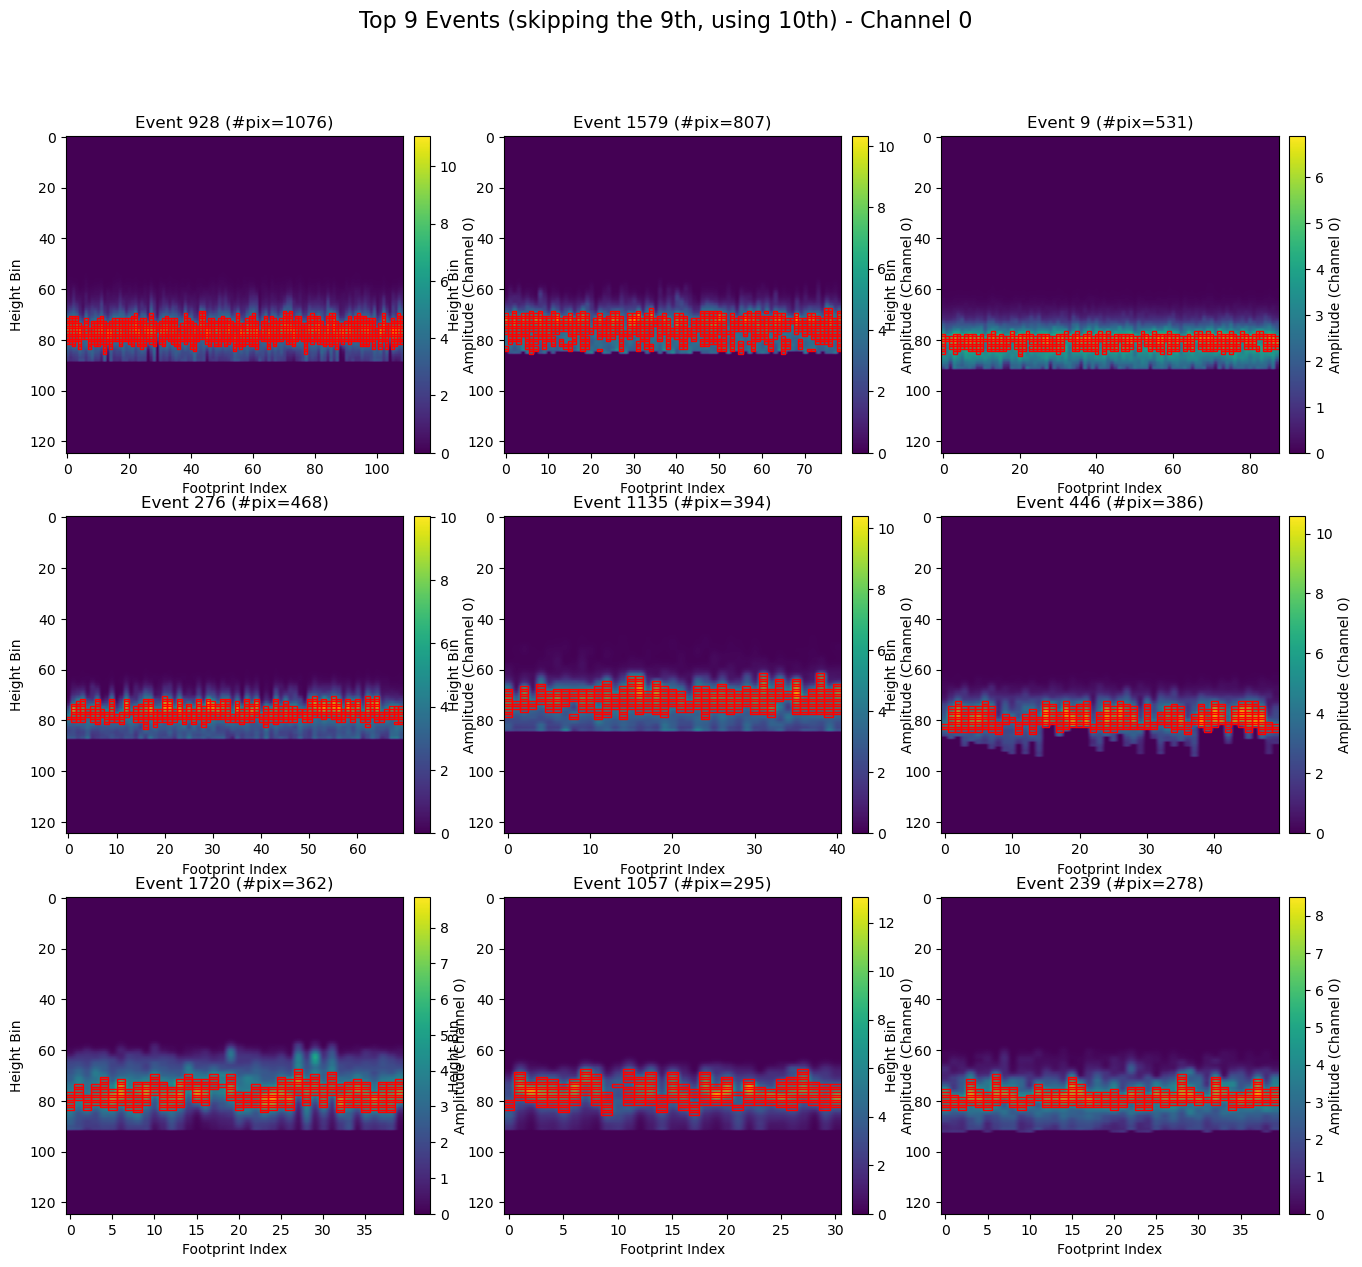

In [11]:
plot_top9_events_channel0(eq_api)

In [96]:
import math as mmmm
import numpy as np
import matplotlib.pyplot as plt

def plot_mean_channel_histograms(eq_api, nrows=1, bins=50):
    """
    For each event in eq_api, we compute the average (over all footprints and height bins)
    for these 5 derived "channels":
      1) Temperature (°C)        => channel 1 (converted from Kelvin by subtracting 273.15)
      2) Specific Humidity       => channel 2
      3) Pressure                => channel 3
      4) Height                  => channel 6
      5) Wind Speed              => sqrt( (U_velocity)^2 + (V_velocity)^2 ), channels 4,5

    We skip:
      - channel 0 (snowfall_rate),
      - channel 7 (gaseous_attenuation),
      - channel 8 (heigh_bin_idx).

    Filtering rules:
      - If temperature < -1270 °C (e.g., -1272.15 outliers), skip that temperature point.
      - If any other channel is -999.0, skip that point for that channel's mean.

    Then we plot 5 histograms of these event-level mean values across all events.

    Parameters
    ----------
    eq_api : EventQueryAPI
        Must support query(..., modes=("3d", show_3d_plots=False)) returning feats_dict,
        where feats_dict entries are arrays of shape (height, 9).
    nrows : int
        Number of subplot rows for the 5 histograms. The columns will be computed automatically.
    bins : int or sequence
        Number of histogram bins or array of bin edges. (Default=50)
    """

    # We'll store each event's mean in these 5 categories:
    cat_temp   = []  # from channel 1, converted K->°C
    cat_hum    = []  # channel 2
    cat_press  = []  # channel 3
    cat_height = []  # channel 6
    cat_wind   = []  # sqrt((U)^2 + (V)^2), from channels 4,5

    events = eq_api.list_events()
    if not events:
        print("No events found in eq_api.")
        return

    for eid in events:
        df, feats_dict = eq_api.query(eid, modes=("3d",), show_3d_plots=False)
        if not feats_dict:
            continue

        # Sums and counts for each channel, so we can skip missing data individually.
        sum_temp = 0.0
        sum_hum = 0.0
        sum_press = 0.0
        sum_height = 0.0
        sum_wind = 0.0

        cnt_temp = 0
        cnt_hum = 0
        cnt_press = 0
        cnt_height = 0
        cnt_wind = 0

        # feats_dict => {(eid, chunk, t, lat_r, lon_r): array(height,9)}
        # channel indices: 0=snowfall,1=temp(K),2=hum,3=pressure,4=U,5=V,6=height,7=gaseous,8=bin_idx
        for _, arr in feats_dict.items():
            height, n_chans = arr.shape
            if n_chans < 9:
                print(f"[WARN] Event {eid} footprint has {n_chans} channels, expected at least 9.")
                continue

            for i in range(height):
                # ---------------------------
                # 1) TEMPERATURE (CHANNEL 1)
                # ---------------------------
                temp_k = arr[i, 1]
                temp_c = temp_k - 273.15  # K -> °C
                # Skip if obviously missing or physically impossible (your threshold)
                if temp_c > -1270:
                    sum_temp += temp_c
                    cnt_temp += 1

                # -----------------------------
                # 2) SPECIFIC HUMIDITY (CH 2)
                # -----------------------------
                hum_val = arr[i, 2]
                if hum_val != -999.0:
                    sum_hum += hum_val
                    cnt_hum += 1

                # ---------------------
                # 3) PRESSURE (CH 3)
                # ---------------------
                press_val = arr[i, 3]
                if press_val != -999.0:
                    sum_press += press_val
                    cnt_press += 1

                # -----------------------------------
                # 4) U & V (CH 4 & 5) => WIND SPEED
                # -----------------------------------
                u_val = arr[i, 4]
                v_val = arr[i, 5]
                if (u_val != -999.0) and (v_val != -999.0):
                    wind_val = mmmm.sqrt(u_val**2 + v_val**2)
                    sum_wind += wind_val
                    cnt_wind += 1

                # -----------------
                # 5) HEIGHT (CH 6)
                # -----------------
                h_val = arr[i, 6]
                if h_val != -999.0:
                    sum_height += h_val
                    cnt_height += 1

        # After going through all footprints for this event, compute means (if we have valid data).
        if cnt_temp > 0:
            mean_temp = sum_temp / cnt_temp
            cat_temp.append(mean_temp)
        if cnt_hum > 0:
            mean_hum = sum_hum / cnt_hum
            cat_hum.append(mean_hum)
        if cnt_press > 0:
            mean_press = sum_press / cnt_press
            cat_press.append(mean_press)
        if cnt_height > 0:
            mean_hgt = sum_height / cnt_height
            cat_height.append(mean_hgt)
        if cnt_wind > 0:
            mean_wind = sum_wind / cnt_wind
            cat_wind.append(mean_wind)

    # Now we have 5 arrays => cat_temp, cat_hum, cat_press, cat_height, cat_wind
    channel_labels = [
        "Temperature (°C)",
        "Specific Humidity (kg/kg)",
        "Pressure (Pa)",
        "Height (m)",       # please verify units if needed
        "Wind Speed (m/s)"
    ]
    channel_data = [
        cat_temp,
        cat_hum,
        cat_press,
        cat_height,
        cat_wind
    ]

    n_plots = 5
    ncols = mmmm.ceil(n_plots / nrows)

    fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axs = np.atleast_1d(axs).flatten()

    for i in range(n_plots):
        ax = axs[i]
        data_i = channel_data[i]
        label_i = channel_labels[i]

        if not data_i:
            ax.set_title(f"{label_i}: No Data")
            ax.axis("off")
            continue

        ax.hist(data_i, bins=bins, edgecolor="black", alpha=0.7)
        ax.set_title(f"{label_i} Distribution", fontsize=12)
        ax.set_ylabel("Number of Events", fontsize=10)
        ax.set_xlabel(label_i, fontsize=10)

    # Hide any leftover subplots (if nrows*ncols > 5).
    for j in range(n_plots, len(axs)):
        axs[j].axis("off")


    plt.savefig("channel_hist.png", dpi=300)
    plt.show()


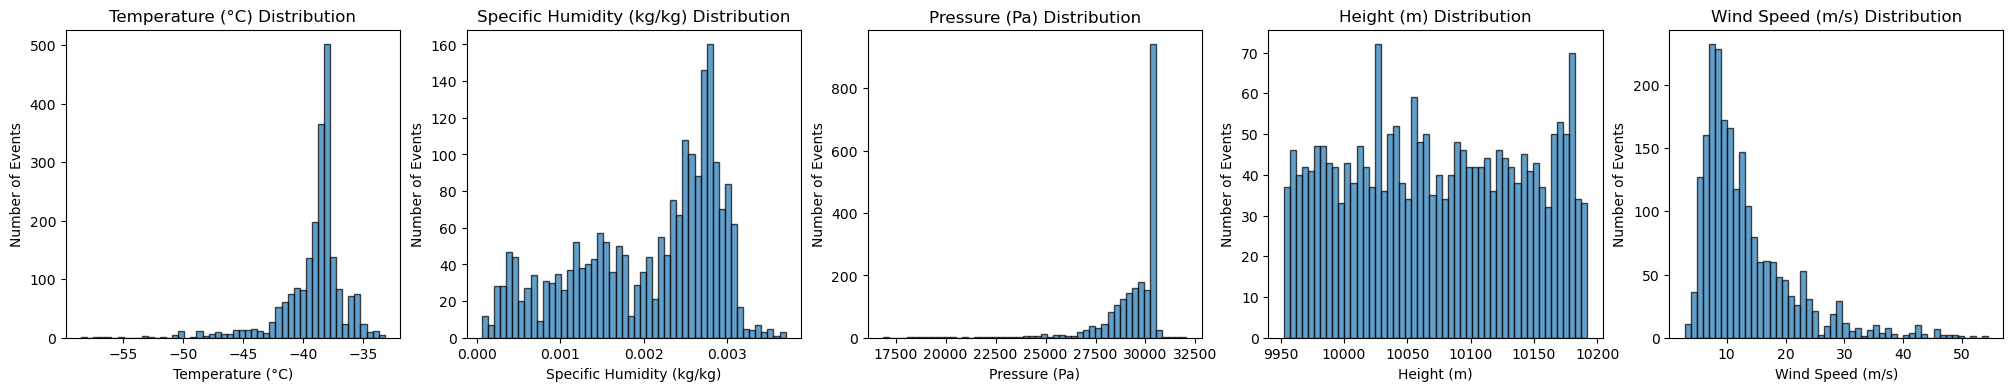

In [97]:
plot_mean_channel_histograms(eq_api, nrows=1, bins=50)

In [18]:
# and for season and months

In [107]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pytz
from timezonefinder import TimezoneFinder

def plot_local_season_distribution(eq_api):
    """
    Plots how many events occur in each local season, split by hemisphere (north vs. south).
    Now with two modifications:
      1) We use the *earliest* footprint's time for each event 
         (i.e., the first/earliest BFS-labeled pixel) 
         instead of median/mean across footprints.
      2) We filter out all events that have fewer than 5 BFS-labeled footprints.

    Steps:
      1) For each event, we do eq_api.query(eid, modes=("2d",)) to get a DataFrame 
         with columns => "Latitude", "Longitude", "TAI_start", "Profile_time", etc.
         - If df has <5 rows, we skip the event entirely.
         - Otherwise, we find the earliest row => min(TAI_start + Profile_time).
           That row's lat, lon, time => local time => local season.
      2) We separate events into 'N' (lat≥0) or 'S' (lat<0).
      3) Tally events across the 4 local seasons. 
      4) Produce a grouped bar chart: x = [Winter, Spring, Summer, Fall],
         two bars = [Northern, Southern].

    Parameters
    ----------
    eq_api : EventQueryAPI
        We'll call eq_api.list_events() => all events,
        then eq_api.query(event_id, modes=("2d",)) => a DataFrame 
        with columns [Latitude, Longitude, TAI_start, Profile_time, ...].
    """

    def month_to_season(month, hemisphere='N'):
        """
        Basic approach:
          - Northern:
            (Dec,Jan,Feb) => Winter
            (Mar,Apr,May) => Spring
            (Jun,Jul,Aug) => Summer
            (Sep,Oct,Nov) => Fall
          - Southern => shift half a year:
            (Dec,Jan,Feb) => Summer
            (Mar,Apr,May) => Fall
            (Jun,Jul,Aug) => Winter
            (Sep,Oct,Nov) => Spring
        """
        if hemisphere.upper() == 'N':
            if month in [12,1,2]:
                return 'Winter'
            elif month in [3,4,5]:
                return 'Spring'
            elif month in [6,7,8]:
                return 'Summer'
            else:
                return 'Fall'
        else:
            # southern hemisphere
            if month in [12,1,2]:
                return 'Summer'
            elif month in [3,4,5]:
                return 'Fall'
            elif month in [6,7,8]:
                return 'Winter'
            else:
                return 'Spring'

    # We'll track event counts by hemisphere => season
    season_counts = {
        'N': {'Winter': 0, 'Spring': 0, 'Summer': 0, 'Fall': 0},
        'S': {'Winter': 0, 'Spring': 0, 'Summer': 0, 'Fall': 0}
    }

    # TAI reference epoch (Jan 1, 1993, UTC)
    TAI_EPOCH_1993 = datetime.datetime(1993,1,1,0,0,0, tzinfo=datetime.timezone.utc)
    tf = TimezoneFinder()

    all_events = eq_api.list_events()
    if not all_events:
        print("No events found in eq_api.")
        return

    for eid in all_events:
        df = eq_api.query(eid, modes=("2d",))
        if df.empty:
            continue

        # 1) Skip event if <5 footprints
        if len(df) < 3:
            continue

        # 2) Among footprints, find the earliest row => min TAI_start+Profile_time
        # We'll create a 'time_s' column => TAI_start+Profile_time
        df['time_s'] = df['TAI_start'] + df['Profile_time']
        # Sort by 'time_s' or just find the min row
        earliest_row = df.loc[df['time_s'].idxmin()]
        # earliest_row => a Series with one footprint's data

        center_lat = earliest_row['Latitude']
        center_lon = earliest_row['Longitude']
        center_tai = earliest_row['time_s']

        # Convert TAI => UTC => local
        utc_dt = TAI_EPOCH_1993 + datetime.timedelta(seconds=float(center_tai))

        tz_name = tf.timezone_at(lng=center_lon, lat=center_lat)
        if not tz_name:
            tz_name = tf.closest_timezone_at(lng=center_lon, lat=center_lat)
        if not tz_name:
            tz_name = 'UTC'
        try:
            local_tz = pytz.timezone(tz_name)
        except Exception:
            local_tz = pytz.UTC

        local_dt = utc_dt.astimezone(local_tz)
        local_month = local_dt.month

        hemisphere = 'N' if center_lat >= 0 else 'S'
        loc_season = month_to_season(local_month, hemisphere=hemisphere)

        # increment count
        season_counts[hemisphere][loc_season] += 1

    # Now we have a dictionary of counts: season_counts['N'][season], season_counts['S'][season]
    # We'll produce a grouped bar chart
    seasons = ['Winter','Spring','Summer','Fall']
    north_vals = [season_counts['N'][s] for s in seasons]
    south_vals = [season_counts['S'][s] for s in seasons]

    x = np.arange(len(seasons))  # 0..3
    width = 0.35

    fig, ax = plt.subplots(figsize=(8,5))
    bar_n = ax.bar(x - width/2, north_vals, width, label='Northern Hemisphere')
    bar_s = ax.bar(x + width/2, south_vals, width, label='Southern Hemisphere')

    ax.set_xlabel("Local Season", fontsize=12)
    ax.set_ylabel("Number of Events", fontsize=12)
    ax.set_title("Distribution of Events by Local Season", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(seasons, fontsize=11)
    ax.legend()

    plt.tight_layout()
    plt.show()


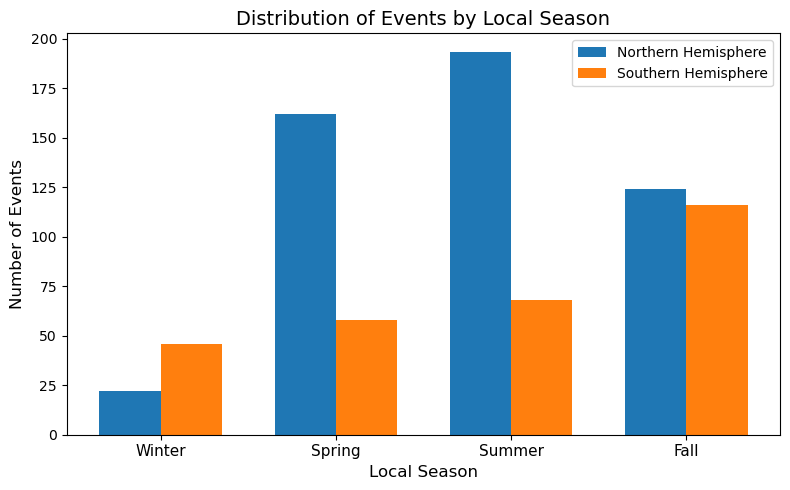

In [108]:
plot_local_season_distribution(eq_api)